# Insights — Datalake énergie

Lecture directe des tables **Gold** (Parquet sur HDFS) avec Pandas.
Aucune requête aux sources d'origine : Gold est prêt à être lu tel quel.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.figsize": (13, 4.5), "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLEU, ORANGE, VERT, ROUGE = "#2E5E8C", "#E08A3C", "#4C9A5A", "#C0392B"

# --- Lecture HDFS -----------------------------------------------------
GOLD = "/datalake/gold"
try:
    import pyarrow.fs as pafs
    fs = pafs.HadoopFileSystem(host="namenode", port=8020)
    rd = lambda t: pd.read_parquet(f"{GOLD}/{t}", filesystem=fs)
except Exception as e:
    print(f"HDFS indisponible ({e}), lecture locale.")
    rd = lambda t: pd.read_parquet(f"./gold_local/{t}")

mix = rd("mix_horaire").sort_values("ts_utc").reset_index(drop=True)
kpi = rd("kpi_daily").sort_values("date_local").reset_index(drop=True)

print(f"mix_horaire : {len(mix):,} lignes, {mix.ts_utc.min()} -> {mix.ts_utc.max()}")
print(f"kpi_daily   : {len(kpi):,} jours")
mix.head(3)

HDFS indisponible (Unable to load libhdfs
LoadLibrary(hdfs.dll) failed
LoadLibrary(./hdfs.dll) failed), lecture locale.
mix_horaire : 8,783 lignes, 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
kpi_daily   : 366 jours


,ts_utc,zone_id,consumption_mw,forecast_j1_mw,forecast_j_mw,co2_rate_g_kwh,physical_exchange_mw,n_points,bioenergies,charbon,...,cloud_cover_pct,ts_local,renewable_share_pct,forecast_error_mw,quality_rank,quality,window_start,window_end,year,month
0,2024-01-01 00:00:00,fr,53174.0,52837.5,51587.5,21.0,-6919.5,2,1225.5,17.0,...,63.80,2024-01-01 01:00:00,36.576232,336.5,0,definitive,2024-01-01,2024-12-31,2024,1
1,2024-01-01 01:00:00,fr,53082.5,51550.0,51112.5,21.0,-6718.5,2,1231.0,17.0,...,68.90,2024-01-01 02:00:00,36.133657,1532.5,0,definitive,2024-01-01,2024-12-31,2024,1
2,2024-01-01 02:00:00,fr,50892.0,48950.0,48375.0,22.5,-4808.0,2,1232.0,17.0,...,74.35,2024-01-01 03:00:00,32.427957,1942.0,0,definitive,2024-01-01,2024-12-31,2024,1


## 1. Chiffres clés de la période

In [2]:
tot = kpi.consumption_gwh.sum()
print(f"Consommation totale        {tot:>12,.0f} GWh")
print(f"Pic de consommation        {kpi.peak_mw.max():>12,.0f} MW"
      f"  le {kpi.loc[kpi.peak_mw.idxmax(),'date_local']}")
print(f"Part renouvelable moyenne  {kpi.renewable_share_pct.mean():>12.1f} %")
print(f"Intensité carbone moyenne  {kpi.co2_avg_g_kwh.mean():>12.1f} g/kWh")
print(f"Température moyenne        {kpi.temperature_avg_c.mean():>12.1f} °C")
print(f"MAE prévision J-1 de RTE   {kpi.forecast_mae_mw.mean():>12,.0f} MW")

Consommation totale             439,984 GWh
Pic de consommation              85,342 MW  le 2024-01-10
Part renouvelable moyenne          29.3 %
Intensité carbone moyenne          19.0 g/kWh
Température moyenne                13.1 °C
MAE prévision J-1 de RTE          1,428 MW


## 2. Consommation et température — la corrélation qui structure tout

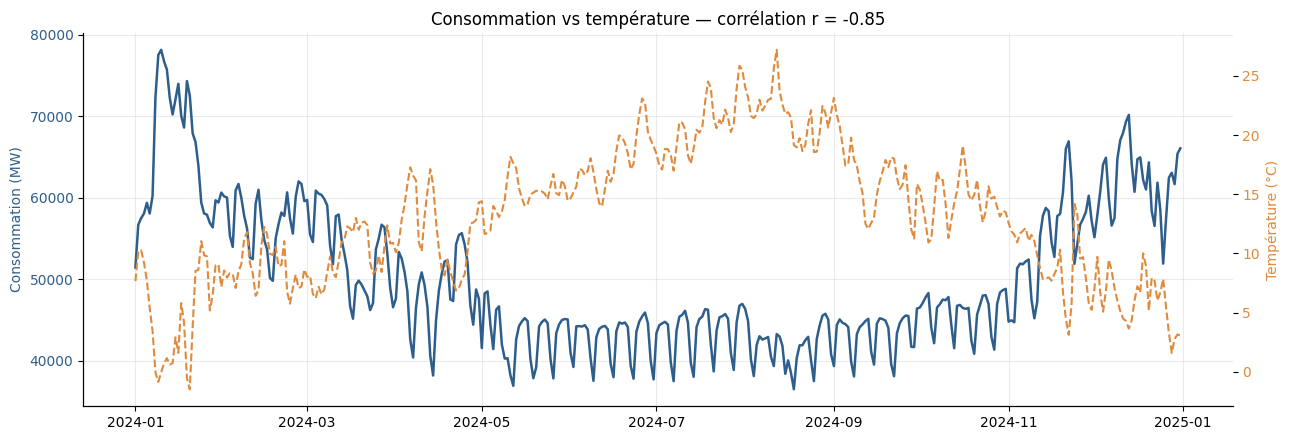

In [3]:
fig, ax1 = plt.subplots()
ax1.plot(kpi.date_local, kpi.consumption_avg_mw, color=BLEU, lw=1.8, label="Consommation")
ax1.set_ylabel("Consommation (MW)", color=BLEU)
ax1.tick_params(axis="y", labelcolor=BLEU)

ax2 = ax1.twinx()
ax2.plot(kpi.date_local, kpi.temperature_avg_c, color=ORANGE, lw=1.5,
         ls="--", label="Température")
ax2.set_ylabel("Température (°C)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)
ax2.grid(False)

r = kpi[["consumption_avg_mw","temperature_avg_c"]].corr().iloc[0,1]
ax1.set_title(f"Consommation vs température — corrélation r = {r:.2f}")
plt.tight_layout(); plt.show()

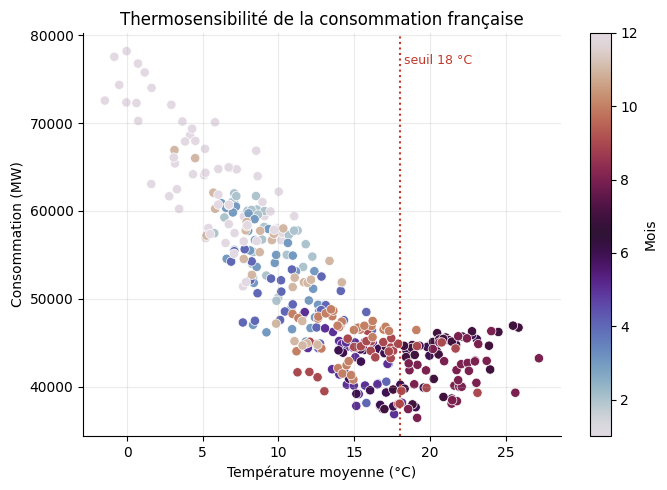

Gradient de chauffage : 1,827 MW par °C sous 18 °C


In [4]:
# La relation est en V : chauffage à gauche, climatisation à droite.
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(kpi.temperature_avg_c, kpi.consumption_avg_mw,
                c=kpi.date_local.map(lambda d: d.month), cmap="twilight",
                s=45, edgecolor="white", lw=.5)
ax.axvline(18, color=ROUGE, ls=":", lw=1.5)
ax.text(18.3, ax.get_ylim()[1]*.97, "seuil 18 °C", color=ROUGE, va="top", fontsize=9)
ax.set_xlabel("Température moyenne (°C)"); ax.set_ylabel("Consommation (MW)")
ax.set_title("Thermosensibilité de la consommation française")
plt.colorbar(sc, label="Mois"); plt.tight_layout(); plt.show()

# Pente de chauffage : MW gagnés par degré perdu sous 18 °C
froid = kpi[kpi.temperature_avg_c < 18]
if len(froid) > 5:
    p = np.polyfit(froid.temperature_avg_c, froid.consumption_avg_mw, 1)
    print(f"Gradient de chauffage : {-p[0]:,.0f} MW par °C sous 18 °C")

## 3. Mix de production

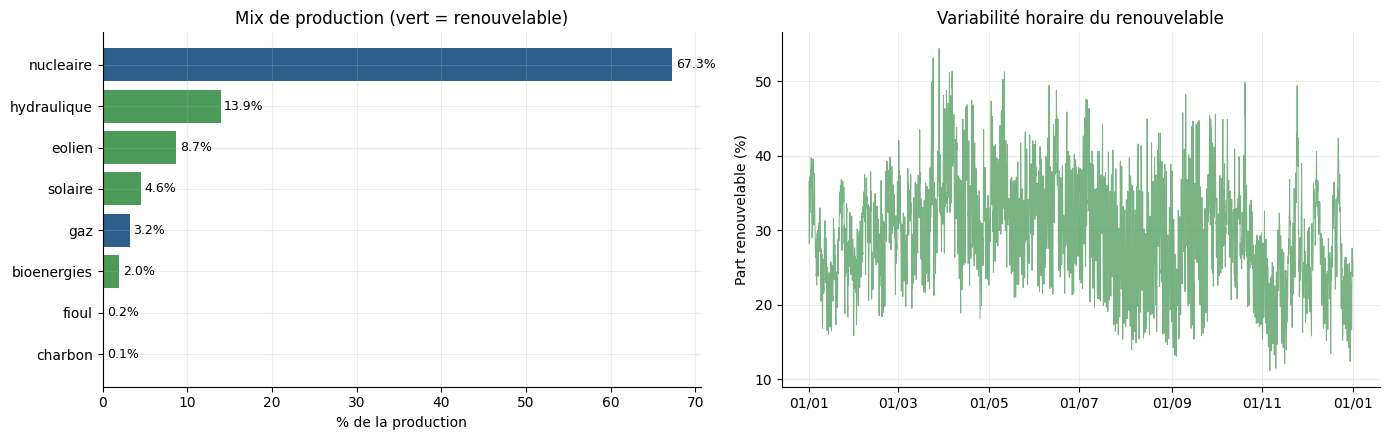

In [5]:
FIL = [c for c in ["nucleaire","gaz","charbon","fioul","hydraulique",
                   "eolien","eolien_terrestre","eolien_offshore",
                   "solaire","bioenergies"] if c in mix.columns]
tot_fil = mix[FIL].sum().sort_values(ascending=False)
part = 100 * tot_fil / tot_fil.sum()

fig, (a,b) = plt.subplots(1, 2, figsize=(14,4.5))
cols = [VERT if f in ("eolien","solaire","hydraulique","bioenergies",
                      "eolien_terrestre","eolien_offshore") else BLEU
        for f in part.index]
a.barh(part.index[::-1], part.values[::-1], color=cols[::-1])
a.set_xlabel("% de la production"); a.set_title("Mix de production (vert = renouvelable)")
for i,v in enumerate(part.values[::-1]):
    a.text(v+.4, i, f"{v:.1f}%", va="center", fontsize=9)

b.plot(mix.ts_utc, mix.renewable_share_pct, color=VERT, lw=.7, alpha=.75)
b.set_ylabel("Part renouvelable (%)"); b.set_title("Variabilité horaire du renouvelable")
b.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout(); plt.show()

## 4. Profil journalier — pourquoi l'heure locale compte

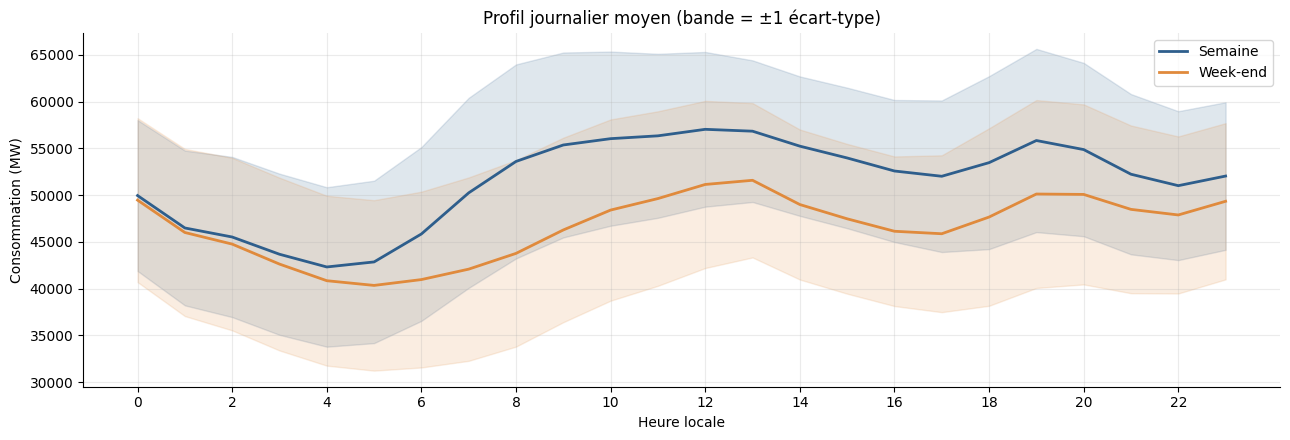

In [6]:
mix["hour_local"] = pd.to_datetime(mix.ts_local).dt.hour
mix["is_we"] = pd.to_datetime(mix.ts_local).dt.dayofweek >= 5

fig, ax = plt.subplots()
for we, lbl, c in [(False,"Semaine",BLEU), (True,"Week-end",ORANGE)]:
    g = mix[mix.is_we==we].groupby("hour_local").consumption_mw
    m, s = g.mean(), g.std()
    ax.plot(m.index, m.values, color=c, lw=2, label=lbl)
    ax.fill_between(m.index, m-s, m+s, color=c, alpha=.15)
ax.set_xlabel("Heure locale"); ax.set_ylabel("Consommation (MW)")
ax.set_xticks(range(0,24,2)); ax.legend()
ax.set_title("Profil journalier moyen (bande = ±1 écart-type)")
plt.tight_layout(); plt.show()

## 5. Qualité de la prévision RTE

`forecast_error_mw` = consommation réelle − prévision J-1. C'est le
benchmark contre lequel le modèle ML doit se comparer.

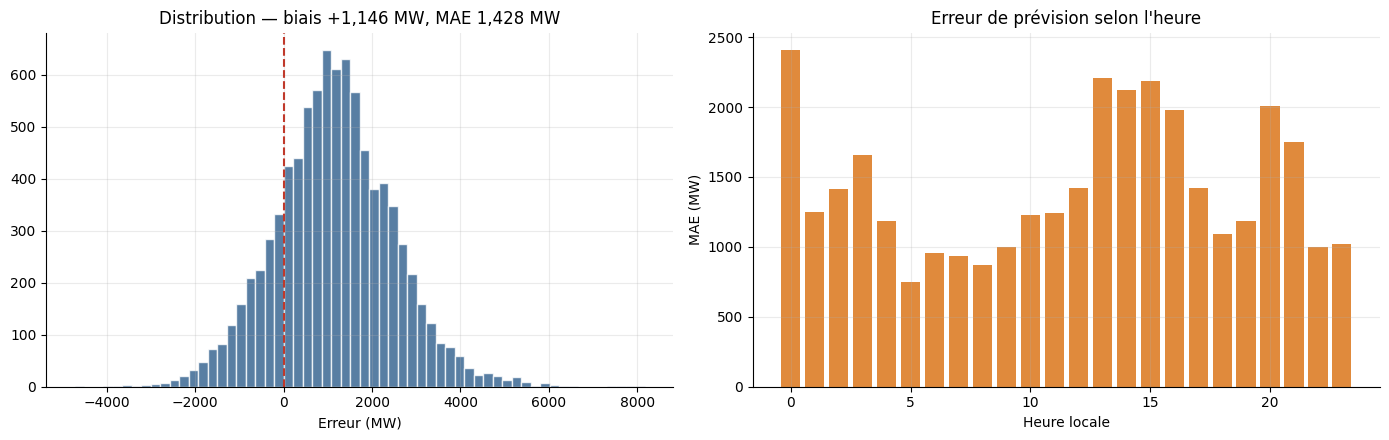

MAPE de RTE : 2.86 %


In [7]:
err = mix.forecast_error_mw.dropna()
fig, (a,b) = plt.subplots(1, 2, figsize=(14,4.5))
a.hist(err, bins=60, color=BLEU, alpha=.8, edgecolor="white")
a.axvline(0, color=ROUGE, ls="--")
a.set_xlabel("Erreur (MW)"); a.set_title(
    f"Distribution — biais {err.mean():+,.0f} MW, MAE {err.abs().mean():,.0f} MW")

by_h = mix.dropna(subset=["forecast_error_mw"]).groupby("hour_local") \
          .forecast_error_mw.apply(lambda s: s.abs().mean())
b.bar(by_h.index, by_h.values, color=ORANGE)
b.set_xlabel("Heure locale"); b.set_ylabel("MAE (MW)")
b.set_title("Erreur de prévision selon l'heure")
plt.tight_layout(); plt.show()

print(f"MAPE de RTE : {(err.abs()/mix.consumption_mw.dropna()).mean()*100:.2f} %")

## 6. Intensité carbone

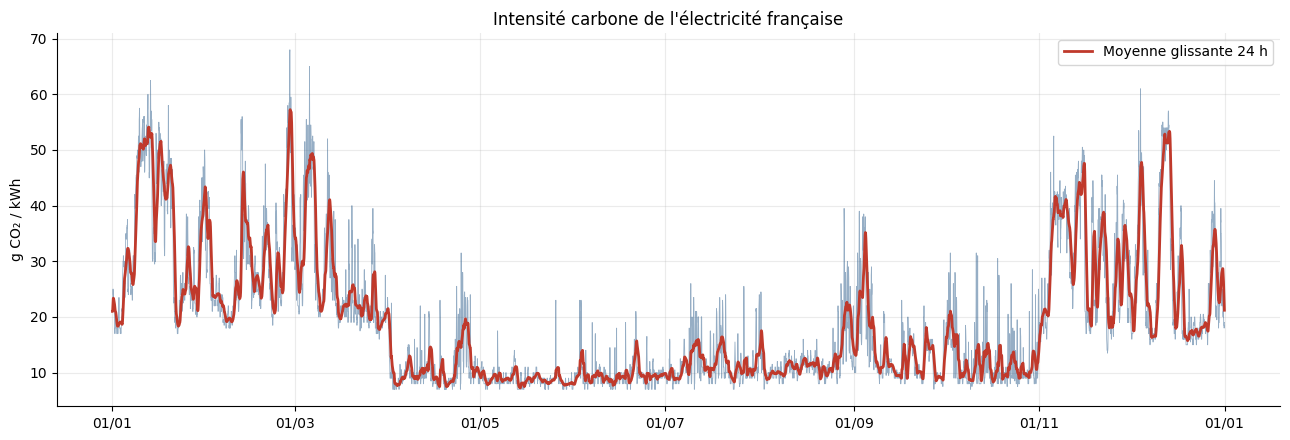

Jour le plus propre : 2024-05-13  7 g/kWh  (renouvelable 33 %)
Jour le plus carboné: 2024-02-28  56 g/kWh  (renouvelable 27 %)


In [8]:
fig, ax = plt.subplots()
ax.plot(mix.ts_utc, mix.co2_rate_g_kwh, color=BLEU, lw=.6, alpha=.5)
roll = mix.set_index("ts_utc").co2_rate_g_kwh.rolling("24h").mean()
ax.plot(roll.index, roll.values, color=ROUGE, lw=2, label="Moyenne glissante 24 h")
ax.set_ylabel("g CO₂ / kWh"); ax.legend()
ax.set_title("Intensité carbone de l'électricité française")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout(); plt.show()

best = kpi.loc[kpi.co2_avg_g_kwh.idxmin()]
worst = kpi.loc[kpi.co2_avg_g_kwh.idxmax()]
print(f"Jour le plus propre : {best.date_local}  {best.co2_avg_g_kwh:.0f} g/kWh"
      f"  (renouvelable {best.renewable_share_pct:.0f} %)")
print(f"Jour le plus carboné: {worst.date_local}  {worst.co2_avg_g_kwh:.0f} g/kWh"
      f"  (renouvelable {worst.renewable_share_pct:.0f} %)")

## 7. Résultats du modèle

Chargement de `models/metrics.json` produit par `train_forecast.py`.

,mae_mw,rmse_mw,mape_pct,bias_mw
benchmark_rte_j1,1440.84,1808.07,2.52,-1045.94
ridge,2702.71,3432.02,4.72,-1161.99
gradient_boosting,2983.55,3838.30,5.12,-1893.45
baseline_persistance,4717.34,6059.05,8.40,-675.59



Meilleur modele : ridge, MAE 2703 MW = 1.88x le MAE de la prevision J-1 de RTE.


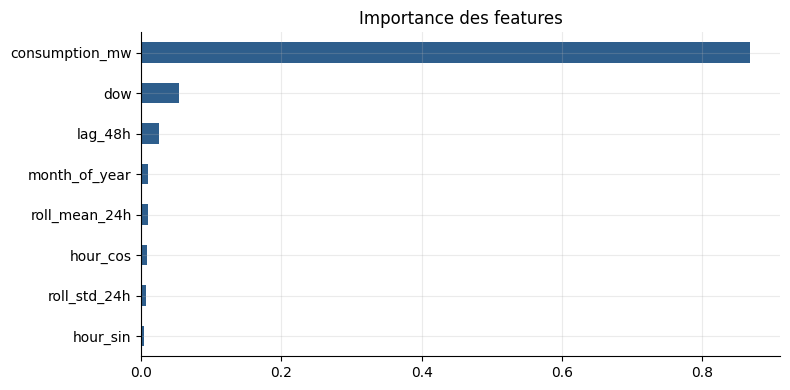

In [9]:
import json, pathlib

p = next((pathlib.Path(c) for c in
          ["./models/metrics.json", "../models/metrics.json",
           "/opt/datalake/models/metrics.json"]
          if pathlib.Path(c).exists()), None)

if p:
    m = json.loads(p.read_text())
    res = pd.DataFrame(m["results"]).T.sort_values("mae_mw")
    display(res.round(2))
    modeles = [r for r in res.index if r in ("ridge", "gradient_boosting")]
    if modeles and "benchmark_rte_j1" in res.index:
        best = res.loc[modeles, "mae_mw"].idxmin()
        ratio = res.loc[best, "mae_mw"] / res.loc["benchmark_rte_j1", "mae_mw"]
        print(f"\nMeilleur modele : {best}, MAE {res.loc[best, 'mae_mw']:.0f} MW "
              f"= {ratio:.2f}x le MAE de la prevision J-1 de RTE.")
        # RTE reste devant : resultat attendu. RTE a des donnees de comptage
        # temps reel et des previsions meteo fines que ce pipeline n'a pas.
    imp = pd.Series(m["importances"]).sort_values()
    imp.plot.barh(color=BLEU, figsize=(8, 4), title="Importance des features")
    plt.tight_layout(); plt.show()
else:
    print("models/metrics.json introuvable — lancer d'abord src/ml/train_forecast.py")


## Conclusion

Les deux sources hétérogènes se croisent bien sur `(ts_utc, zone_id)` : la
corrélation consommation/température n'existe que parce que le CSV RTE et
le JSON Open-Meteo ont été normalisés vers un modèle commun en Silver.

Le modèle reste derrière la prévision J-1 de RTE, ce qui est le résultat
attendu : RTE dispose de données de comptage et de prévisions
météorologiques fines que ce pipeline n'a pas.